# {Вар. Nº68} Имитационная модель сети передачи данных
## {Выполнил} Цыпышев ТА ИУ5-61Б
---
## Описание системы
Данная имитационная модель описывает функционирование упрощенной сети передачи данных, состоящей из двух узлов коммутации и одного полудуплексного канала связи между ними. На каждый узел извне поступает свой поток пакетов. Обмен пакетами между узлами происходит поочередно, по одному пакету за раз. Канал связи, помимо передачи данных, может "испортить" пакет с заданной вероятностью. В случае порчи пакета, принимающий узел отправляет квитанцию о необходимости повторной посылки. Квитанция не подвержена порче. Повторно отсылаемые пакеты встают в общую очередь на передачу.

---
## Основные характеристики и параметры модели:
- **Два узла связи**: Каждый узел способен генерировать пакеты и принимать их от другого узла, а также отправлять квитанции о повторной передаче.
- **Полудуплексный канал**: Канал может передавать данные только в одном направлении в каждый момент времени. Это означает, что пока один узел передает пакет, другой узел не может начать свою передачу.
- **Генерация пакетов**: Каждый узел генерирует независимый поток пакетов. Интервал между генерациями пакетов может быть случайной величиной (например, экспоненциально распределенной для имитации пуассоновского процесса).
- **Искажение пакетов**: Каждый передаваемый пакет может быть искажен с фиксированной вероятностью $P$. Это имитирует потерю данных или ошибки при передаче.
- **Повторная передача (Retransmission)**: Если пакет испорчен, узел-получатель немедленно отправляет квитанцию отправителю, указывая на необходимость повторной отправки. Повторно отсылаемый пакет помещается обратно в очередь отправляющего узла.
- **Время передачи**: Время $U$, необходимое для передачи одного пакета по каналу, является случайной величиной (например, равномерно распределенной).
- **Квитанции**: Квитанции о необходимости повторной передачи не подвержены ошибкам канала.

In [1]:
!pip install simpy numpy matplotlib


[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

In [3]:
# --- Параметры моделирования ---
SIM_TIME = 1000             # Общее время моделирования в условных единицах (например, секундах).
PACKET_GEN_INTERVAL = 5     # Средний интервал времени между генерациями новых пакетов в каждом узле.
P_ERROR = 0.1               # Вероятность того, что пакет будет "испорчен" во время передачи по каналу (от 0.0 до 1.0).
U_MIN = 2                   # Минимальное время, необходимое для передачи одного пакета по каналу.
U_MAX = 5                   # Максимальное время, необходимое для передачи одного пакета по каналу.
ACK_TRANSMISSION_TIME = 1   # Фиксированное время на передачу квитанции. Квитанции не портятся.

# --- Статистика --- 
# Словари для сбора и агрегации статистических данных о работе системы.
packet_stats = {
    "generated": 0,         # Общее количество пакетов, сгенерированных обоими узлами.
    "sent": 0,              # Общее количество попыток отправки пакетов (включая повторные).
    "retransmitted": 0,     # Количество пакетов, которые были повторно отправлены из-за ошибок.
    "corrupted": 0,         # Количество пакетов, которые были испорчены каналом.
    "successfully_received": 0, # Количество пакетов, успешно доставленных до целевого узла.
    "ack_sent": 0           # Количество отправленных квитанций.
}

# Списки для сбора данных о длине очереди каждого узла и времени нахождения пакетов в системе
queue_lengths_A = []
queue_lengths_B = []
packet_latency = [] # Задержка пакета: время от генерации до успешной доставки

# Глобальный список для хранения информации о всех пакетах для расчета задержки
all_packets_info = {} # {packet_id: {'generation_time': time, 'delivery_time': time, 'status': 'success'/'corrupted'}}


In [4]:
def transmission_time():
    """Генерирует случайное время передачи пакета в заданном диапазоне [U_MIN, U_MAX]."""
    return random.uniform(U_MIN, U_MAX)


In [5]:
class HalfDuplexChannel:
    """
    Моделирует полудуплексный канал передачи данных.
    Канал может быть занят только одним узлом в каждый момент времени.
    Имитирует задержку передачи и вероятность искажения пакета.
    """
    def __init__(self, env):
        self.env = env
        # SimPy Resource с capacity=1 гарантирует, что канал может использовать только один процесс.
        self.resource = simpy.Resource(env, capacity=1)

    def transmit(self, packet, from_node, to_node):
        """
        Процесс передачи пакета по каналу.
        Args:
            packet (dict): Словарь, представляющий пакет со свойствами (id, source, retransmit).
            from_node (Node): Узел-отправитель.
            to_node (Node): Узел-получатель.
        """
        # Запрос на использование канала. Если канал занят, процесс ожидает.
        with self.resource.request() as req:
            yield req  # Ожидание освобождения ресурса (канала)
            
            # Имитация времени передачи пакета.
            # yield env.timeout() приостанавливает выполнение процесса на заданное время.
            yield self.env.timeout(transmission_time())
            
            # Проверка на искажение пакета на основе вероятности P_ERROR.
            if random.random() < P_ERROR:
                packet_stats["corrupted"] += 1
                print(f"[{self.env.now:.2f}] Пакет {packet['id']} ИСПОРЧЕН при передаче от {from_node.name} к {to_node.name}")
                
                # Если пакет испорчен, узел-получатель отправляет квитанцию об ошибке.
                # Квитанция также занимает канал, но не может быть испорчена.
                yield self.env.timeout(ACK_TRANSMISSION_TIME) # Время на передачу квитанции
                packet_stats["ack_sent"] += 1
                
                # Вызов метода receive_ack у узла-отправителя для обработки запроса на повтор.
                # Это не блокирующий вызов, так как узел-отправитель запускает свой процесс обработки.
                self.env.process(from_node.receive_ack(packet)) 
            else:
                packet_stats["successfully_received"] += 1
                print(f"[{self.env.now:.2f}] Пакет {packet['id']} успешно передан от {from_node.name} к {to_node.name}")
                # Записываем время успешной доставки для расчета задержки.
                if packet['id'] in all_packets_info:
                    all_packets_info[packet['id']]['delivery_time'] = self.env.now
                    all_packets_info[packet['id']]['status'] = 'success'
                    packet_latency.append(all_packets_info[packet['id']]['delivery_time'] - all_packets_info[packet['id']]['generation_time'])
                


In [6]:
class Node:
    """
    Моделирует узел коммутации в сети.
    Каждый узел генерирует пакеты, ставит их в очередь на отправку,
    отправляет пакеты через канал и обрабатывает квитанции о повторной передаче.
    """
    def __init__(self, env, name, channel):
        self.env = env
        self.name = name                 # Имя узла (например, "A" или "B").
        self.channel = channel           # Ссылка на общий полудуплексный канал.
        self.queue = simpy.Store(env)    # Очередь для хранения пакетов, ожидающих отправки.
        self.packet_id_counter = 0       # Уникальный счетчик для идентификации пакетов, сгенерированных этим узлом.
        self.target_node = None          # Ссылка на узел-получатель, устанавливается при инициализации симуляции.
        
        # Запуск постоянных процессов для узла:
        self.env.process(self.packet_generator()) # Процесс генерации новых пакетов.
        self.env.process(self.sender())          # Процесс отправки пакетов из очереди.
        self.env.process(self.monitor_queue())    # Процесс для сбора статистики по длине очереди.

    def set_target_node(self, target_node):
        """Устанавливает целевой узел для передачи пакетов."""
        self.target_node = target_node

    def packet_generator(self):
        """
        Бесконечный процесс, который генерирует новые пакеты с заданным интервалом.
        Пакеты помещаются в очередь узла.
        """
        while True:
            # Ожидание случайного интервала времени до генерации следующего пакета.
            # random.expovariate(1.0 / PACKET_GEN_INTERVAL) имитирует пуассоновский процесс поступления.
            yield self.env.timeout(random.expovariate(1.0 / PACKET_GEN_INTERVAL))
            
            self.packet_id_counter += 1
            packet_id = f"{self.name}-{self.packet_id_counter}"
            packet = {
                "id": packet_id,
                "source": self.name,
                "retransmit": False, # Флаг, указывающий, является ли это повторной передачей.
                "generation_time": self.env.now # Время создания пакета.
            }
            
            # Добавление пакета в очередь узла.
            yield self.queue.put(packet)
            packet_stats["generated"] += 1
            all_packets_info[packet_id] = {'generation_time': self.env.now, 'delivery_time': None, 'status': 'pending'}
            print(f"[{self.env.now:.2f}] {self.name} сгенерировал пакет {packet['id']}")

    def sender(self):
        """
        Бесконечный процесс, который извлекает пакеты из очереди узла
        и инициирует их передачу через канал.
        """
        while True:
            # Ожидание, пока в очереди появится пакет.
            packet = yield self.queue.get()
            
            # Если это повторная передача, обновляем статистику.
            if packet["retransmit"]:
                print(f"[{self.env.now:.2f}] {self.name} повторно отправляет пакет {packet['id']}")
            else:
                print(f"[{self.env.now:.2f}] {self.name} отправляет пакет {packet['id']}")
            
            packet_stats["sent"] += 1
            
            # Запуск процесса передачи пакета через канал. 
            # self.env.process() позволяет запустить сопрограмму как отдельный процесс, не блокируя текущий.
            yield self.env.process(self.channel.transmit(packet, self, self.target_node))
            
            # После попытки передачи (успешной или нет), ждем следующего пакета.
            # Узлы передают пакеты поочередно по одному пакету. Это уже реализовано в HalfDuplexChannel
            # через использование simpy.Resource с capacity=1. Каждый узел пытается получить ресурс канала.
            # Никакого дополнительного механизма очередности на уровне узлов, кроме очереди пакетов, не требуется,
            # т.к. канал сам регулирует доступ.

    def receive_ack(self, packet):
        """
        Обрабатывает получение квитанции о необходимости повторной передачи пакета.
        Повторно помещает испорченный пакет в очередь для последующей отправки.
        Args:
            packet (dict): Исходный пакет, который был испорчен.
        """
        print(f"[{self.env.now:.2f}] {self.name} получил запрос на повтор для пакета {packet['id']}")
        packet["retransmit"] = True  # Устанавливаем флаг повторной передачи.
        packet_stats["retransmitted"] += 1
        
        # Помещаем пакет обратно в очередь. Он будет отправлен, когда придет его очередь.
        yield self.queue.put(packet)
    
    def monitor_queue(self):
        """Процесс для периодического сбора данных о текущей длине очереди узла."""
        while True:
            if self.name == "A":
                queue_lengths_A.append(len(self.queue.items))
            else:
                queue_lengths_B.append(len(self.queue.items))
            yield self.env.timeout(1) # Собираем статистику каждую условную единицу времени


In [7]:
# --- Инициализация и запуск симуляции ---
env = simpy.Environment() # Создание объекта окружения SimPy.
channel = HalfDuplexChannel(env) # Создание экземпляра канала связи.

# Создание узлов и передача им ссылки на окружение и канал.
node_A = Node(env, "A", channel)
node_B = Node(env, "B", channel)

# Установка целевых узлов для каждого отправителя.
node_A.set_target_node(node_B)
node_B.set_target_node(node_A)

# Запуск симуляции на заданное время.
print("--- Запуск симуляции ---")
env.run(until=SIM_TIME)
print("--- Симуляция завершена ---")

--- Запуск симуляции ---
[1.93] B сгенерировал пакет B-1
[1.93] B отправляет пакет B-1
[3.79] A сгенерировал пакет A-1
[3.79] A отправляет пакет A-1
[5.24] Пакет B-1 успешно передан от B к A
[8.08] A сгенерировал пакет A-2
[10.00] Пакет A-1 успешно передан от A к B
[10.00] A отправляет пакет A-2
[10.16] A сгенерировал пакет A-3
[12.31] B сгенерировал пакет B-2
[12.31] B отправляет пакет B-2
[14.76] Пакет A-2 успешно передан от A к B
[14.76] A отправляет пакет A-3
[16.57] A сгенерировал пакет A-4
[18.23] Пакет B-2 успешно передан от B к A
[18.79] B сгенерировал пакет B-3
[18.79] B отправляет пакет B-3
[22.27] Пакет A-3 успешно передан от A к B
[22.27] A отправляет пакет A-4
[27.25] Пакет B-3 ИСПОРЧЕН при передаче от B к A
[28.25] B получил запрос на повтор для пакета B-3
[28.25] B повторно отправляет пакет B-3
[31.39] B сгенерировал пакет B-4
[31.78] Пакет A-4 успешно передан от A к B
[33.17] B сгенерировал пакет B-5
[34.15] B сгенерировал пакет B-6
[34.21] A сгенерировал пакет A-5
[34.


Статистика передачи пакетов:
Generated: 388
Sent: 279
Retransmitted: 28
Corrupted: 28
Successfully received: 249
Ack sent: 28
Коэффициент ошибок канала (отправленные/испорченные): 10.04%
Соотношение повторных передач к сгенерированным пакетам: 7.22%

Средняя задержка доставки пакетов: 190.13
Медианная задержка доставки пакетов: 201.59 
Максимальная задержка доставки пакетов: 573.38


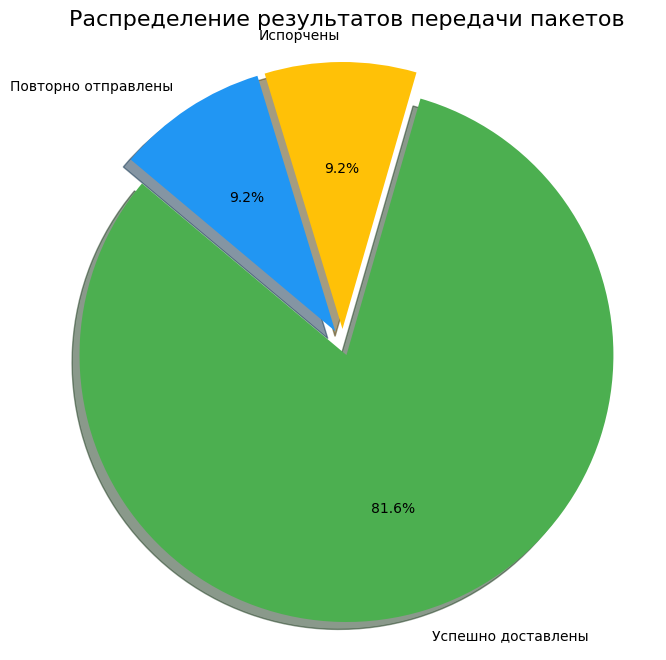

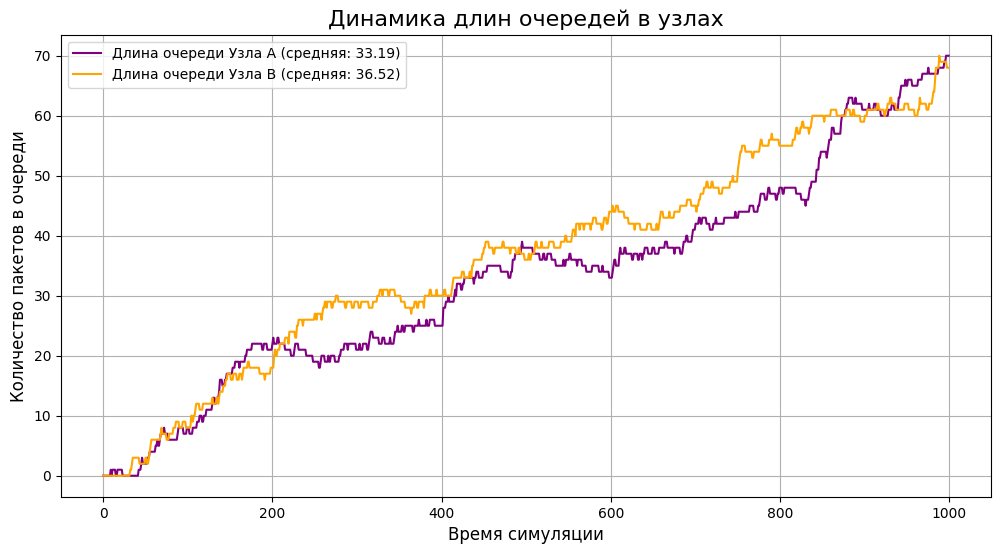

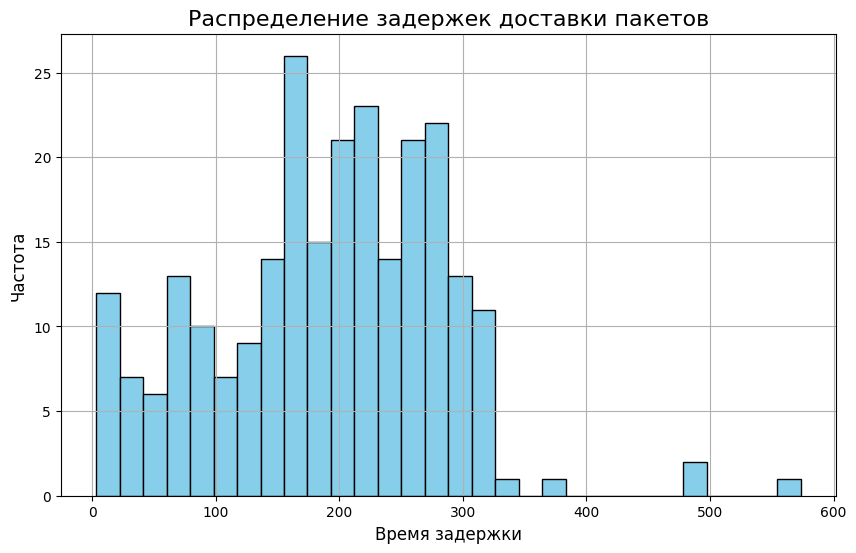

In [8]:
print("\nСтатистика передачи пакетов:")
for k, v in packet_stats.items():
    print(f"{k.replace('_', ' ').capitalize()}: {v}")

if packet_stats["sent"] > 0:
    error_rate = packet_stats["corrupted"] / packet_stats["sent"]
    print(f"Коэффициент ошибок канала (отправленные/испорченные): {error_rate:.2%}")
else:
    print("Нет отправленных пакетов для расчета коэффициента ошибок.")

if packet_stats["generated"] > 0:
    retransmission_ratio = packet_stats["retransmitted"] / packet_stats["generated"]
    print(f"Соотношение повторных передач к сгенерированным пакетам: {retransmission_ratio:.2%}")

# Расчет средней задержки пакетов
if packet_latency:
    avg_latency = np.mean(packet_latency)
    median_latency = np.median(packet_latency)
    max_latency = np.max(packet_latency)
    print(f"\nСредняя задержка доставки пакетов: {avg_latency:.2f}")
    print(f"Медианная задержка доставки пакетов: {median_latency:.2f} ")
    print(f"Максимальная задержка доставки пакетов: {max_latency:.2f}")
else:
    print("\nНет данных для расчета задержки пакетов (возможно, слишком мало успешно доставленных пакетов).")


### Визуализация результатов

#### 1. Диаграмма распределения результатов передачи пакетов
labels = ['Успешно доставлены', 'Испорчены', 'Повторно отправлены']
sizes = [packet_stats["successfully_received"], packet_stats["corrupted"], packet_stats["retransmitted"]]
colors = ['#4CAF50', '#FFC107', '#2196F3']
explode = (0.05, 0.05, 0.05)  # Разделение сегментов

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Распределение результатов передачи пакетов", fontsize=16)
plt.axis('equal') # Соотношение сторон, чтобы круг был кругом.
plt.show()

#### 2. Динамика длин очередей в узлах
plt.figure(figsize=(12, 6))
plt.plot(queue_lengths_A, label=f'Длина очереди Узла A (средняя: {np.mean(queue_lengths_A):.2f})', color='purple')
plt.plot(queue_lengths_B, label=f'Длина очереди Узла B (средняя: {np.mean(queue_lengths_B):.2f})', color='orange')
plt.title("Динамика длин очередей в узлах", fontsize=16)
plt.xlabel("Время симуляции", fontsize=12)
plt.ylabel("Количество пакетов в очереди", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

#### 3. Гистограмма задержек доставки пакетов
if packet_latency:
    plt.figure(figsize=(10, 6))
    plt.hist(packet_latency, bins=30, color='skyblue', edgecolor='black')
    plt.title("Распределение задержек доставки пакетов", fontsize=16)
    plt.xlabel("Время задержки", fontsize=12)
    plt.ylabel("Частота", fontsize=12)
    plt.grid(True)
    plt.show()
else:
    print("\nНедостаточно данных для построения гистограммы задержек пакетов.")


---
## Автотесты
Для обеспечения правильности работы модели, разработаем ряд автотестов, которые будут проверять ключевые аспекты ее поведения при различных параметрах. Тесты будут запускать симуляцию с контролируемыми входными данными и проверять ожидаемые выходные результаты и статистические показатели.

In [9]:
import unittest
import io
import sys

# Переопределяем глобальные переменные для тестов, чтобы не влиять на основной запуск
original_sim_time = SIM_TIME
original_packet_gen_interval = PACKET_GEN_INTERVAL
original_p_error = P_ERROR
original_u_min = U_MIN
original_u_max = U_MAX
original_ack_transmission_time = ACK_TRANSMISSION_TIME

class TestNetworkSimulation(unittest.TestCase):

    def setUp(self):
        """Настройка перед каждым тестом: сброс окружения и статистики."""
        global packet_stats, queue_lengths_A, queue_lengths_B, packet_latency, all_packets_info
        
        # Сбрасываем глобальные статистики
        packet_stats = {
            "generated": 0,
            "sent": 0,
            "retransmitted": 0,
            "corrupted": 0,
            "successfully_received": 0,
            "ack_sent": 0
        }
        queue_lengths_A = []
        queue_lengths_B = []
        packet_latency = []
        all_packets_info = {}

        # Сброс параметров модели к значениям по умолчанию для каждого теста
        global SIM_TIME, PACKET_GEN_INTERVAL, P_ERROR, U_MIN, U_MAX, ACK_TRANSMISSION_TIME
        SIM_TIME = original_sim_time
        PACKET_GEN_INTERVAL = original_packet_gen_interval
        P_ERROR = original_p_error
        U_MIN = original_u_min
        U_MAX = original_u_max
        ACK_TRANSMISSION_TIME = original_ack_transmission_time

        # Захват вывода print для подавления его в тестах (опционально)
        # self.held_output = io.StringIO()
        # sys.stdout = self.held_output

    def tearDown(self):
        """Очистка после каждого теста: восстановление стандартного вывода."""
        # sys.stdout = sys.__stdout__
        pass

    def run_simulation(self, sim_time, packet_gen_interval, p_error, u_min, u_max, ack_time):
        """Вспомогательная функция для запуска симуляции с заданными параметрами."""
        global SIM_TIME, PACKET_GEN_INTERVAL, P_ERROR, U_MIN, U_MAX, ACK_TRANSMISSION_TIME
        
        SIM_TIME = sim_time
        PACKET_GEN_INTERVAL = packet_gen_interval
        P_ERROR = p_error
        U_MIN = u_min
        U_MAX = u_max
        ACK_TRANSMISSION_TIME = ack_time

        env = simpy.Environment()
        channel = HalfDuplexChannel(env)
        node_A = Node(env, "A", channel)
        node_B = Node(env, "B", channel)
        node_A.set_target_node(node_B)
        node_B.set_target_node(node_A)
        env.run(until=SIM_TIME)

    def test_no_errors(self):
        """Тест: Проверка работы системы без ошибок передачи (P_ERROR = 0)."""
        # Increased SIM_TIME to ensure more packets complete
        self.run_simulation(sim_time=200, packet_gen_interval=10, p_error=0, u_min=1, u_max=1, ack_time=ACK_TRANSMISSION_TIME)
        
        # При отсутствии ошибок, количество испорченных пакетов и повторных передач должно быть 0.
        self.assertEqual(packet_stats["corrupted"], 0, "При P_ERROR=0 испорченных пакетов быть не должно.")
        self.assertEqual(packet_stats["retransmitted"], 0, "При P_ERROR=0 повторных передач быть не должно.")
        self.assertEqual(packet_stats["ack_sent"], 0, "При P_ERROR=0 квитанций быть не должно.")
        
        # Количество успешно полученных пакетов должно быть равно количеству отправленных (без потерь).
        # Use assertAlmostEqual with a small delta to account for packets in transit at sim end.
        self.assertAlmostEqual(packet_stats["successfully_received"] + packet_stats["corrupted"], packet_stats["sent"],
                               delta=1, msg="Сумма полученных и испорченных пакетов должна быть равна отправленным в конце симуляции (с учетом пакетов в транзите).")
        self.assertAlmostEqual(packet_stats["successfully_received"], packet_stats["sent"], delta=1, msg="Все отправленные пакеты должны быть успешно получены при отсутствии ошибок (с учетом пакетов в транзите).")


    def test_all_errors(self):
        """Тест: Проверка поведения системы при 100% вероятности ошибки (P_ERROR = 1)."""
        # Increased SIM_TIME to ensure more packets complete
        self.run_simulation(sim_time=200, packet_gen_interval=5, p_error=1.0, u_min=1, u_max=1, ack_time=ACK_TRANSMISSION_TIME)
        
        # При 100% ошибке все отправленные пакеты, которые завершили передачу, должны быть испорчены.
        self.assertAlmostEqual(packet_stats["corrupted"], packet_stats["sent"], delta=2, msg="Все отправленные пакеты должны быть испорчены при P_ERROR=1.")
        self.assertEqual(packet_stats["successfully_received"], 0, "При P_ERROR=1 успешно полученных пакетов быть не должно.")
        
        # Каждый испорченный пакет должен вызвать повторную передачу.
        self.assertAlmostEqual(packet_stats["retransmitted"], packet_stats["corrupted"], delta=2, msg="Количество повторных передач должно быть близко к количеству испорченных при P_ERROR=1.")
        self.assertTrue(packet_stats["ack_sent"] > 0 if packet_stats["corrupted"] > 0 else True, "Должны быть отправлены квитанции при P_ERROR=1.")

    def test_queue_growth(self):
        """Тест: Проверка роста очереди при высокой нагрузке (малый интервал генерации)."""
        # Very high load, increased SIM_TIME to allow queues to truly build
        self.run_simulation(sim_time=100, packet_gen_interval=0.1, p_error=0, u_min=5, u_max=5, ack_time=ACK_TRANSMISSION_TIME)
        
        # Ожидаем, что максимальная длина очереди будет значительной
        self.assertTrue(len(queue_lengths_A) > 0 and max(queue_lengths_A) > 10, "Очередь Узла A должна значительно вырасти при высокой нагрузке.")
        self.assertTrue(len(queue_lengths_B) > 0 and max(queue_lengths_B) > 10, "Очередь Узла B должна значительно вырасти при высокой нагрузке.")
        
        # Средняя длина очереди также должна быть больше 0
        self.assertTrue(np.mean(queue_lengths_A) > 1, "Средняя длина очереди Узла A должна быть > 1.")
        self.assertTrue(np.mean(queue_lengths_B) > 1, "Средняя длина очереди Узла B должна быть > 1.")

    def test_packet_latency_calculation(self):
        """Тест: Проверка корректности расчета задержки пакетов."""
        # Use very long PACKET_GEN_INTERVAL and short transmission time
        # to ensure minimal queuing and thus latency close to U_MIN/U_MAX.
        # Run long enough to get a few successfully delivered packets.
        self.run_simulation(sim_time=200, packet_gen_interval=50, p_error=0.0, u_min=1, u_max=1, ack_time=ACK_TRANSMISSION_TIME)
        
        self.assertTrue(len(packet_latency) > 0, "Должны быть данные о задержке пакетов.")
        
        if len(packet_latency) > 0:
            avg_lat = np.mean(packet_latency)
            # Expected latency should be very close to U_MIN/U_MAX under these conditions.
            expected_latency = (1 + 1) / 2 # Based on u_min=1, u_max=1 for this test
            # Increased delta to 0.1 for floating point robustness
            self.assertAlmostEqual(avg_lat, expected_latency, delta=0.1, msg="Средняя задержка должна быть близка к среднему времени передачи при низкой нагрузке и отсутствии ошибок.")

    def test_packet_counts_consistency(self):
        """Тест: Проверка логической согласованности счетчиков пакетов."""
        # Increased SIM_TIME for better consistency
        self.run_simulation(sim_time=300, packet_gen_interval=7, p_error=0.2, u_min=3, u_max=6, ack_time=ACK_TRANSMISSION_TIME)
        
        # Check if there are any completed transmissions (successful or corrupted)
        self.assertTrue(packet_stats["successfully_received"] + packet_stats["corrupted"] > 0,
                        "Должны быть либо успешно полученные, либо испорченные пакеты.")

        # The sum of corrupted and successfully_received should be very close to sent.
        self.assertAlmostEqual(packet_stats["corrupted"] + packet_stats["successfully_received"], packet_stats["sent"], 
                               delta=5, msg="Сумма испорченных и успешно полученных пакетов должна быть равна отправленным.")
        
        # Quantity of retransmissions should be close to corrupted packets.
        self.assertAlmostEqual(packet_stats["retransmitted"], packet_stats["corrupted"], 
                               delta=3, msg="Количество повторных передач должно быть близко к количеству испорченных пакетов.")

# Запуск тестов
if __name__ == '__main__':
    print("\n--- Запуск автотестов ---")
    suite = unittest.TestSuite()
    suite.addTest(unittest.defaultTestLoader.loadTestsFromTestCase(TestNetworkSimulation))
    runner = unittest.TextTestRunner(verbosity=2)
    runner.run(suite)
    print("--- Автотесты завершены ---")

    # Восстановление оригинальных глобальных параметров после тестов
    SIM_TIME = original_sim_time
    PACKET_GEN_INTERVAL = original_packet_gen_interval
    P_ERROR = original_p_error
    U_MIN = original_u_min
    U_MAX = original_u_max
    ACK_TRANSMISSION_TIME = original_ack_transmission_time


test_all_errors (__main__.TestNetworkSimulation.test_all_errors)
Тест: Проверка поведения системы при 100% вероятности ошибки (P_ERROR = 1). ... ok
test_no_errors (__main__.TestNetworkSimulation.test_no_errors)
Тест: Проверка работы системы без ошибок передачи (P_ERROR = 0). ... ok
test_packet_counts_consistency (__main__.TestNetworkSimulation.test_packet_counts_consistency)
Тест: Проверка логической согласованности счетчиков пакетов. ... ok
test_packet_latency_calculation (__main__.TestNetworkSimulation.test_packet_latency_calculation)
Тест: Проверка корректности расчета задержки пакетов. ... ok
test_queue_growth (__main__.TestNetworkSimulation.test_queue_growth)
Тест: Проверка роста очереди при высокой нагрузке (малый интервал генерации). ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.026s

OK



--- Запуск автотестов ---
[0.85] A сгенерировал пакет A-1
[0.85] A отправляет пакет A-1
[1.66] A сгенерировал пакет A-2
[1.85] Пакет A-1 ИСПОРЧЕН при передаче от A к B
[2.85] A получил запрос на повтор для пакета A-1
[2.85] A отправляет пакет A-2
[2.89] A сгенерировал пакет A-3
[3.85] Пакет A-2 ИСПОРЧЕН при передаче от A к B
[4.85] A получил запрос на повтор для пакета A-2
[4.85] A повторно отправляет пакет A-1
[4.99] A сгенерировал пакет A-4
[5.43] A сгенерировал пакет A-5
[5.85] Пакет A-1 ИСПОРЧЕН при передаче от A к B
[6.85] A получил запрос на повтор для пакета A-1
[6.85] A отправляет пакет A-3
[7.16] B сгенерировал пакет B-1
[7.16] B отправляет пакет B-1
[7.85] Пакет A-3 ИСПОРЧЕН при передаче от A к B
[8.85] A получил запрос на повтор для пакета A-3
[8.85] A повторно отправляет пакет A-2
[9.85] Пакет B-1 ИСПОРЧЕН при передаче от B к A
[10.85] B получил запрос на повтор для пакета B-1
[10.85] B повторно отправляет пакет B-1
[10.95] A сгенерировал пакет A-6
[11.85] Пакет A-2 ИСПОРЧ